In [ ]:
!pip -q install bitsandbytes accelerate
!pip -q install langchain
!pip install einops
!pip install --upgrade --quiet  langchain-community qdrant-client
!pip install langchainhub
!pip install -U langchain-huggingface
!pip -q install PyMuPDF tqdm aiolimiter faiss-cpu PyPDF2 pdfplumber rouge-score bert-score evaluate
!pip install -U --quiet "sentence-transformers==5.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.2/470.2 kB 34.4 MB/s eta 0:00:00


In [ ]:
import torch
import faiss
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM
from peft import PeftModel
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple, Optional, Sequence, Union, Iterable
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import re
from spacy.lang.en import English
import fitz
from time import perf_counter as timer
import textwrap
from transformers import (AutoProcessor, AutoModelForVision2Seq,
                          MllamaForConditionalGeneration, EarlyStoppingCallback,
                          AutoTokenizer, TrainingArguments, Trainer,
                          set_seed, pipeline)
from PIL import Image
import requests
import ast
from langchain.text_splitter import TokenTextSplitter
from torch.nn.functional import normalize
import nest_asyncio
from google.colab import userdata
from aiolimiter import AsyncLimiter
import urllib.parse, pathlib
import html, unicodedata
import spacy
from sentence_transformers import SentenceTransformer, InputExample, losses, util
from sentence_transformers.trainer import SentenceTransformerTrainer, SentenceTransformerTrainingArguments
from torch.utils.data import DataLoader
from pathlib import Path
from itertools import chain
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed
import torch.nn.functional as F
import torch.nn as nn
from datasets import Dataset as HFDataset
from tqdm.auto import tqdm
from utils import *
import evaluate
from datasets import Dataset
import os, random, time, json, statistics, asyncio, logging, openai, tiktoken
import itertools
import gc
from openai import AsyncOpenAI
from scipy.stats import ttest_rel
import urllib.parse

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#train_pdf_paths = ['/content/drive/MyDrive/fMRIwork/rag_docs/ales.pdf']

In [ ]:
test_dir = '/content/drive/MyDrive/fMRIwork/rag_docs/testing'
pdf_paths = [
    os.path.join(test_dir, fname)
    for fname in os.listdir(test_dir)
    if fname.lower().endswith('.pdf')
]

In [ ]:
len(pdf_paths)

17

# Doc loading and processing

In [ ]:
processed_pages = get_cleaned_and_processed_pages(pdf_paths)

In [ ]:
len(processed_pages)

409

In [ ]:
processed_pages[0].keys()

dict_keys(['doc_num', 'doc_source', 'page_number', 'page_char_count', 'page_word_count', 'page_sentence_count_raw', 'page_token_count', 'text', 'metadata'])

In [ ]:
processed_pages[0]['metadata']['sentences']

['Post-Operative Instructions: Laparoscopic Cholecystectomy These instructions provide general guidelines.',
 'Your surgeon will give you specific instructions tailored to your procedure.',
 "Always follow your surgeon's advice.",
 'Contact your surgeon immediately if you have any concerns.',
 'After a laparoscopic cholecystectomy, you should rest, avoid heavy lifting, and eat a high-fiber diet.',
 'You should also keep the incision clean.',
 'Rest and Activity \u200b Rest when tired, but avoid prolonged bed rest.',
 '\u200b Gentle exercise like walking is encouraged to prevent blood clots, starting the day after surgery.',
 '\u200b Avoid strenuous activities (jogging, weightlifting) for 10-15 days, or as advised by your surgeon.',
 'Avoid activities that cause pain or pull on incisions.',
 "Return to work will depend on your job's physical demands and your recovery progress.",
 "Discuss with your doctor when it's safe to drive (typically after a week, if not on strong pain medication 

In [ ]:
retr_model_path = "/content/drive/MyDrive/SurgiRAG/retriever_finetuned/outputs/retriever_fast/sentence_transformer"
retr_model = SentenceTransformer(retr_model_path).to("cuda")

In [ ]:
embeddings, text_chunks, chunk_meta = embed_text(processed_pages, retr_model, batch_size=64)

Total chunks: 1,527


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Embeddings tensor shape: torch.Size([1527, 768])


In [ ]:
index_path = "indices/docs.idx"
Path(index_path).parent.mkdir(parents=True, exist_ok=True)

_ = build_index(
        embeddings,
        index_path = index_path,
        use_gpu    = False,
        hnsw_m     = None
    )

Building exact IndexFlatIP …
Index built with 1,527 vectors  |  dim = 768
Index saved to: indices/docs.idx


# RAG Pipline

In [ ]:
adapter_dir  = "/content/drive/MyDrive/SurgiRAG/bioasq_rag_optimized/lora-bioasq-rag"
base_gen_model   = "meta-llama/Llama-3.2-11B-Vision-Instruct"

In [ ]:
class RAGPipeline:
    def __init__(self,
                 retriever_model_path: str,
                 corpus_chunks: list[str],
                 chunk_meta: list[dict] | None = None,
                 faiss_index: "faiss.Index" = None,
                 faiss_index_path: str | None = None,
                 shared_retriever=None,
                 reranker_model_name: str | None = "BAAI/bge-reranker-large",
                 shared_reranker=None,
                 generator_base_model: str | None = "meta-llama/Llama-3.2-11B-Vision-Instruct",
                 generator_lora_path: str | None = None,
                 generator_object=None,
                 system_prompt: str | None = None):

        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.corpus = corpus_chunks
        self.meta   = chunk_meta if chunk_meta is not None else [{} for _ in range(len(corpus_chunks))]

        # Retriever
        if shared_retriever is not None:
            self.retriever = shared_retriever
        else:
            self.retriever = SentenceTransformer(retriever_model_path)
            if torch.cuda.is_available():
                self.retriever = self.retriever.to("cuda")

        # FAISS index
        if faiss_index is not None:
            self.index = faiss_index
        elif faiss_index_path is not None:
            index = faiss.read_index(faiss_index_path)
            if torch.cuda.is_available():
                # keep on CPU to save VRAM; comment‑out if we need GPU
                # res = faiss.StandardGpuResources()
                # index = faiss.index_cpu_to_gpu(res, 0, index)
                pass
            self.index = index
        else:
            raise ValueError("Need faiss_index or faiss_index_path")

        # Reranker
        if reranker_model_name is None:
            self.reranker_model = None
            self.reranker_tokenizer = None
        elif shared_reranker is not None:
            self.reranker_model = shared_reranker
            self.reranker_tokenizer = AutoTokenizer.from_pretrained(reranker_model_name)
        else:
            self.reranker_tokenizer = AutoTokenizer.from_pretrained(reranker_model_name)
            self.reranker_model = AutoModelForSequenceClassification.from_pretrained(
                reranker_model_name).to(self.device).eval()

        # Generator
        if generator_object is not None:
            self.generator_model = generator_object
            self.generator_tokenizer = AutoTokenizer.from_pretrained(
                generator_base_model, trust_remote_code=True)
        else:
            if generator_base_model is None:
                raise ValueError("Need generator_base_model when "
                                 "generator_object is None.")
            dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
            self.generator_tokenizer = AutoTokenizer.from_pretrained(
                generator_base_model, trust_remote_code=True)
            base_model = AutoModelForCausalLM.from_pretrained(
                generator_base_model,
                device_map="auto",
                torch_dtype=dtype,
                trust_remote_code=True,
            )
            if generator_lora_path:
                base_model = PeftModel.from_pretrained(
                    base_model, generator_lora_path).merge_and_unload()
            self.generator_model = base_model.eval()

        # prompt
        self.system_prompt = system_prompt

    def retrieve(self, query: str, top_k: int = 20, rerank_k: int = 5):
        """Dense retrieval + optional cross-encoder rerank."""
        # Encode & search FAISS
        if top_k <= 0:
            return []
        q_vec = self.retriever.encode(query, convert_to_numpy=True,
                                      normalize_embeddings=True).astype("float32")
        scores, indices = self.index.search(q_vec.reshape(1, -1), top_k)
        indices = indices.flatten()
        if len(indices) == 0:
            return []

        candidate_texts = [self.corpus[i] for i in indices]

        # No-reranker shortcut
        if self.reranker_model is None or self.reranker_tokenizer is None:
            take = rerank_k if rerank_k is not None else top_k

            return [
                {"text": self.corpus[i],
                 "score": float(scores[0][j]),
                 "index": int(i),
                 "meta": self.meta[i]}
                for j, i in enumerate(indices[:take])
            ]

        # Cross-encoder reranking
        pairs  = [(query, passage) for passage in candidate_texts]
        inputs = self.reranker_tokenizer(pairs, padding=True, truncation=True, max_length=512, return_tensors='pt')
        inputs = {k: v.to(self.reranker_model.device) for k, v in inputs.items()}
        with torch.inference_mode():
            logits = self.reranker_model(**inputs).logits.squeeze(-1).cpu().numpy().astype(float)

        ranked = logits.argsort()[::-1][:rerank_k]

        return [
            {"text": self.corpus[indices[i]],
            "score": float(logits[i]),
            "index": int(indices[i]),
             "meta": self.meta[indices[i]]}
            for i in ranked
        ]


    def generate_answer(self, query: str, context_items: list, max_new_tokens: int = 256, temperature: float = 0.0, return_prompt: bool = False):
        """Generate answer given the query and retrieved context_items."""
        #Make prompt with system message, context and query
        prompt = self.system_prompt
        for item in context_items:
            # Each context item as a bullet point in prompt
            ctx_text = item["text"].replace("\n", " ")
            prompt += f"- {ctx_text}\n"
        prompt += f"Query: {query}\nAnswer:"
        prompt = prompt.lstrip()

        # Tokenize prompt (truncated if too long for context window)
        inputs = self.generator_tokenizer(prompt, return_tensors='pt', truncation=True,
                                         max_length=self.generator_tokenizer.model_max_length)
        inputs = {k: v.to(self.device) for k,v in inputs.items()}
        # Text generation with the LLM
        with torch.inference_mode(), torch.autocast(device_type=self.device, dtype=torch.bfloat16, enabled=(self.device=='cuda')):
            output_ids = self.generator_model.generate(**inputs,
                                                      max_new_tokens=max_new_tokens,
                                                      temperature=temperature,
                                                      do_sample=(temperature > 0.0),
                                                      pad_token_id=self.generator_tokenizer.eos_token_id)
        output_text = self.generator_tokenizer.decode(output_ids[0], skip_special_tokens=True)
        #Clean prompt:
        answer = output_text[len(prompt):].strip()
        junk_phrases = ["Sure, here is the answer:", "Certainly:", "Certainly. "]
        for jp in junk_phrases:
            answer = answer.replace(jp, "")
        if return_prompt:
            return answer, prompt
        return answer

    def __call__(self, query: str, return_context: bool = False):
        """End-to-end answer generation for a given query. If return_context is True, also return the retrieved context passages."""
        context_items = self.retrieve(query)
        if len(context_items) == 0:
            return ("I'm sorry, I could not find relevant information to answer that.", []) if return_context else \
                   "I'm sorry, I could not find relevant information to answer that."
        answer = self.generate_answer(query, context_items)
        return (answer, context_items) if return_context else answer

# Eval/Ablation

In [ ]:
SYSTEM_PROMPT_FEWSHOT = """Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages before answering.
Do **NOT** reveal your reasoning; output only the answer in an explanatory style.

Example 1:
Query: What is the most serious complication of laparoscopic cholecystectomy?
Answer: The most serious complication is bile duct injury (BDI). Although relatively rare (~0.2–0.4 %), it can lead to re‑operations, higher mortality, reduced quality of life, and litigation.

Example 2:
Query: Why is the critical view of safety important in laparoscopic cholecystectomy?
Answer: The critical view of safety prevents bile duct injury by ensuring anatomy is clearly identified before division. It requires clearing the hepatocystic triangle of fat and tissue, separating the gallbladder from the liver, and confirming that only the cystic duct and cystic artery are seen entering the gallbladder.

Now use the context items below to answer the user query. Cite sources like [1], [2], etc.
Context:
"""


# SYSTEM_PROMPT_NO_FEWSHOT = """You are a surgical QA assistant. Use ONLY the provided context to answer.
# Be concise, factual, and cite only information present in the context.
# Context:
# """

In [ ]:
def evaluate_retrieval(
    retriever,
    faiss_index,
    queries: list[str],
    gold_doc_ids: list[set[int]],
    top_k: int = 20,
    batch_size: int = 64,
):
    """Return corpus‑level metrics and per‑query arrays."""

    # Encode all queries in batches
    q_vecs = retriever.encode(
        queries,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype("float32")

    # Single FAISS call for all queries
    scores, all_indices = faiss_index.search(q_vecs, top_k)   # (N, K)

    # Vectorized metrics
    log_discounts = 1.0 / np.log2(np.arange(2, top_k + 2))    # (K,)

    recall_vec      = np.zeros(len(queries))
    rr_vec          = np.zeros(len(queries))
    ndcg_vec        = np.zeros(len(queries))

    for i, retrieved in enumerate(all_indices):
        rel_mask          = np.in1d(retrieved, list(gold_doc_ids[i]), assume_unique=True)
        if rel_mask.any():
            recall_vec[i] = 1.0
            first_rel_idx = np.argmax(rel_mask)
            rr_vec[i]     = 1.0 / (first_rel_idx + 1)

            dcg = (rel_mask * log_discounts).sum()
            ideal_len = min(len(gold_doc_ids[i]), top_k)
            ideal_dcg = log_discounts[:ideal_len].sum()
            ndcg_vec[i] = dcg / ideal_dcg
        else:
            # no relevant docs retrieved
            recall_vec[i] = rr_vec[i] = ndcg_vec[i] = 0.0

    return (
        {"Recall@20": recall_vec.mean(), "MRR": rr_vec.mean(), "nDCG@20": ndcg_vec.mean()},
        {"recall": recall_vec.tolist(), "rr": rr_vec.tolist(), "ndcg": ndcg_vec.tolist()}
    )


In [ ]:
BIOBERT_PATH = "pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb"

In [ ]:
bleu_metric      = evaluate.load("bleu")
rouge_metric     = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")

#on cpu to save vram
device_cpu = "cpu"

factcc_tokenizer = AutoTokenizer.from_pretrained("manueldeprada/FactCC")
factcc_model = AutoModelForSequenceClassification.from_pretrained("manueldeprada/FactCC").to(device_cpu)
factcc_model.eval()

nli_tokenizer    = AutoTokenizer.from_pretrained("facebook/bart-large-mnli")
nli_model    = AutoModelForSequenceClassification.from_pretrained("facebook/bart-large-mnli").to(device_cpu)
nli_model.eval()

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/854 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

BartForSequenceClassification(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50265, 1024, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50265, 1024, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
       

In [ ]:
@torch.inference_mode()
def _batched_factcc(ctx_batch, ans_batch, tok, model):
    enc = tok(ctx_batch, ans_batch, truncation= True,
              padding=True, max_length=512, return_tensors="pt").to(model.device)
    logits = model(**enc).logits
    probs  = torch.softmax(logits, dim=1)[:, model.config.label2id["CORRECT"]]
    return probs.detach().cpu().numpy()

@torch.inference_mode()
def _batched_nli(ctx_batch, ans_batch, tok, model):
    enc = tok(
        ctx_batch,
        ans_batch,
        truncation=True,
        padding=True,
        max_length=512,
        return_tensors="pt",
    ).to(model.device)
    logits = model(**enc).logits
    probs  = torch.softmax(logits, dim=1)

    ent_idx = model.config.label2id.get("ENTAILMENT", 2)
    entail  = probs[:, ent_idx]
    return entail.detach().cpu().numpy()

def evaluate_generation(preds, refs, ctxs, batch_size=16):
    if ctxs is None:
        raise ValueError("contexts needed for factuality metrics.")

    # Overlap metrics
    bleu = bleu_metric.compute(
        predictions=preds,
        references=[[r] for r in refs],
        max_order=4,
    )["bleu"]

    rouge = rouge_metric.compute(
        predictions=preds,
        references=refs,
        rouge_types=["rougeL"],
        use_stemmer=True,
    )["rougeL"]

    bert_list = bertscore_metric.compute(
        predictions=preds,
        references=refs,
        lang="en",
        batch_size=batch_size,
    )["f1"]
    bert_arr  = np.asarray(bert_list, dtype=float)
    bert_f1   = float(bert_arr.mean())

    # Factuality (FactCC + NLI) batched
    factcc_probs, entail_probs = [], []
    for start in range(0, len(preds), batch_size):
        slice_preds = preds[start:start + batch_size]
        slice_ctxs  = ctxs[start:start + batch_size]
        factcc_probs.extend(_batched_factcc(slice_ctxs, slice_preds,
                                            factcc_tokenizer, factcc_model))
        entail_probs.extend(_batched_nli(slice_ctxs, slice_preds,
                                         nli_tokenizer, nli_model))

    factcc_probs  = np.array(factcc_probs)
    entail_probs  = np.array(entail_probs)

    return {
        "BLEU":           bleu,
        "ROUGE-L_F1":     rouge,
        "BERTScore_F1":   bert_f1,
        "FactCC_acc":     float((factcc_probs > 0.5).mean()),
        "FactCC_conf":    float(factcc_probs.mean()),
        "Entailment_avg": float(entail_probs.mean()),
        "per_query": {
            "bert_f1":   bert_arr.tolist(),
            "factcc":    factcc_probs.tolist(),
            "entail":    entail_probs.tolist(),
        }
    }


In [ ]:
json_path = "/content/drive/MyDrive/fMRIwork/eval/lc_qa_synth.json"
with open(json_path) as f:
    data = json.load(f)
dataset = Dataset.from_list(data)

In [ ]:
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [ ]:
index_cache      = {}
retriever_cache  = {}
CROSS_ENCODER    = None
BASE_GENERATOR   = None

In [ ]:
def get_or_build_index_cpu(retr_path: str):
    if retr_path in index_cache:
        return index_cache[retr_path]

    logging.info("FAISS index for %s …", retr_path)
    retr = retriever_cache.get(retr_path)
    if retr is None:
        retr = SentenceTransformer(retr_path, device="cuda")
        retriever_cache[retr_path] = retr

    # processed_pages already has token_chunks
    embs, _, _ = embed_text(processed_pages, retr, batch_size=128)
    idx = build_index(embs, use_gpu=False)
    index_cache[retr_path] = idx
    torch.cuda.empty_cache()
    return idx

In [ ]:
def get_base_generator():
    """Load LLaMA‑3 11B (fp16) once and reuse."""
    global BASE_GENERATOR
    if BASE_GENERATOR is None:
        BASE_GENERATOR = AutoModelForCausalLM.from_pretrained(
            "meta-llama/Llama-3.2-11B-Vision-Instruct",
            device_map="auto",
            torch_dtype=torch.float16,
        )
        BASE_GENERATOR.eval()
    return BASE_GENERATOR

In [ ]:
# Async LLM‑judge ablation loop
# CONFIG
openai.api_key   = os.getenv("OPENAI_API_KEY")
client           = AsyncOpenAI()
GPT_MODEL        = "gpt-4o-mini"
RATE_LIMIT       = AsyncLimiter(max_rate=60, time_period=60)   # 60 req / min
SAMPLE_N         = 32                                       # per combo
random.seed(42)

# async GPT call
async def _chat(prompt: str, max_tokens: int = 1, temperature: float = 0.0,
                retries: int = 3) -> str:
    for attempt in range(retries):
        try:
            async with RATE_LIMIT:
                resp = await asyncio.wait_for(
                    client.chat.completions.create(
                        model=GPT_MODEL,
                        temperature=temperature,
                        max_tokens=max_tokens,
                        messages=[
                            {"role": "system",
                             "content": "You are a strict evaluator. "
                                        "Answer ONLY with the requested output."},
                            {"role": "user", "content": prompt}
                        ],
                    ),
                    timeout=120,
                )
                return resp.choices[0].message.content.strip()
        except (asyncio.TimeoutError, Exception) as e:
            logging.warning("GPT call failed (attempt %d/%d): %s",
                            attempt + 1, retries, str(e))
            await asyncio.sleep(1 + attempt)
    return ""    # fall‑back

# LLM‑Judge metrics
async def context_precision(question: str, chunks: list[str]) -> float:
    bullets = "\n".join([f"- {c[:300]}" for c in chunks[:5]])
    prompt  = (f"Question: {question}\n\n"
               f"Context chunks:\n{bullets}\n\n"
               "Do these chunks collectively help answer the question? "
               "Reply only YES or NO.")
    resp = await _chat(prompt)
    return 1.0 if resp.lower().startswith("y") else 0.0

async def faithfulness_score(answer: str, context: str) -> float:
    prompt = (f"Context:\n\"\"\"{context[:4096]}\"\"\"\n\n"
              f"Answer:\n\"\"\"{answer[:2048]}\"\"\"\n\n"
              "Does the context fully support every factual claim in the answer? "
              "Respond with a single number 0‑1.")
    resp = await _chat(prompt, max_tokens=3)
    try:
        return float(resp.split()[0])
    except ValueError:
        return 0.0

async def fluency_coherence(answer: str) -> dict[str, float]:
    prompt = ("Rate the answer below on a 1‑5 integer scale for each trait.\n\n"
              "Traits: (A) Fluency/Grammar, (B) Coherence/Logical‑flow.\n\n"
              "Return JSON exactly like {\"fluency\":4, \"coherence\":5}.\n\n"
              f"Answer:\n\"\"\"{answer[:4096]}\"\"\"")
    resp = await _chat(prompt, max_tokens=15)
    try:
        return json.loads(resp)
    except Exception:
        return {"fluency": 1, "coherence": 1}



# EXPERIMENT MATRIX
retriever_variants = {
    "random": None,                 # special-cased
    "base":   BIOBERT_PATH,         # BioBERT encoder
    "fine":   retr_model_path       # FT encoder
}

reranker_variants = {
    "none":  None,
    "cross": "BAAI/bge-reranker-large",
}

generator_variants = {
    "base":   {"base_model": base_gen_model, "lora": None,        "fewshot": True},
    "fine":   {"base_model": base_gen_model, "lora": adapter_dir, "fewshot": True},
}


# Cached heavy models

retriever_cache = {path: SentenceTransformer(path, device="cuda")
                   for path in {v for v in retriever_variants.values() if v}}
cross_encoder = None
base_generator = None  # load once; apply LoRA adapters later when called

results_table = []

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/691 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
dummy_path = BIOBERT_PATH
index_dummy = get_or_build_index_cpu(dummy_path)

Total chunks: 1,527
Embeddings tensor shape: torch.Size([1527, 768])
Building exact IndexFlatIP …
Index built with 1,527 vectors  |  dim = 768


In [ ]:
async def run_one_combo(r_name, rerank_name, g_name, sample_pairs):
    """
    Build a pipeline variant, answer SAMPLE_N questions, gather classic +
    GPT‑judge metrics, and append a dict to `results_table`.
    """
    global CROSS_ENCODER

    # Generator setup
    gen_cfg   = generator_variants[g_name]
    base_gen  = get_base_generator()

    if gen_cfg["lora"] is None:
        generator_to_use = base_gen
    else:
        # apply LoRA, then merge & unload so VRAM stays flat
        # generator_to_use = PeftModel.from_pretrained(
        #     base_gen, gen_cfg["lora"], device_map="auto").merge_and_unload()
        generator_to_use = PeftModel.from_pretrained(
              base_gen, gen_cfg["lora"], device_map="auto"
                ).eval()

    # Retriever + FAISS index
    if r_name == "random":
        index_for_retr = None
    else:
        retr_path      = retriever_variants[r_name]
        index_for_retr = get_or_build_index_cpu(retr_path)

    # Build/Reuse reranker
    if reranker_variants[rerank_name] is None:
        reranker_model_name = None
        shared_reranker_obj = None
    else:
        reranker_model_name = reranker_variants[rerank_name]
        if CROSS_ENCODER is None:
            CROSS_ENCODER = AutoModelForSequenceClassification.from_pretrained(
                reranker_model_name, device_map="auto", torch_dtype=torch.float16
            )
        shared_reranker_obj = CROSS_ENCODER

    use_fs = gen_cfg.get("fewshot", True)

    if r_name == "random":
        class RandomRetriever(RAGPipeline):
            def __init__(self, corpus_chunks, chunk_meta, generator_object):
                self.corpus = corpus_chunks
                self.meta = chunk_meta
                self.device = "cuda" if torch.cuda.is_available() else "cpu"
                self.retriever = None
                self.index = None
                self.reranker_model = None
                self.reranker_tokenizer = None
                self.generator_model = generator_object
                self.generator_tokenizer = AutoTokenizer.from_pretrained(
                    base_gen_model, trust_remote_code=True)
                self.system_prompt = " "

            def retrieve(self, query, top_k=20, rerank_k=5):
                total = len(self.corpus)
                idxs = np.random.choice(total, size=min(top_k, total), replace=False)
                return [{"text": self.corpus[i], "index": int(i), "score": None}
                        for i in idxs[:rerank_k]]

        pipeline_variant = RandomRetriever(
            corpus_chunks=text_chunks,
            chunk_meta=chunk_meta,
            generator_object=generator_to_use
        )
        pipeline_variant.system_prompt = SYSTEM_PROMPT_FEWSHOT # if use_fs else SYSTEM_PROMPT_NO_FEWSHOT

    else:
        pipeline_variant = RAGPipeline(
            retriever_model_path = retriever_variants[r_name],
            corpus_chunks        = text_chunks,
            chunk_meta           = chunk_meta,
            faiss_index          = index_for_retr,
            reranker_model_name  = reranker_model_name,
            generator_object     = generator_to_use,
            shared_reranker      = shared_reranker_obj,
            shared_retriever     = retriever_cache.get(retriever_variants[r_name]),
            system_prompt        = SYSTEM_PROMPT_FEWSHOT # if use_fs else SYSTEM_PROMPT_NO_FEWSHOT,
        )
        pipeline_variant.system_prompt = SYSTEM_PROMPT_FEWSHOT #if use_fs else SYSTEM_PROMPT_NO_FEWSHOT


    # Answer SAMPLE_N questions
    preds, prompts, ctx_texts_joined, ctx_texts_list, refs, qs = [], [], [], [], [], []


    combo_name = f"{r_name}_retr-{rerank_name}_rerank-{g_name}_gen"
    log_dir = "logs"
    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, combo_name + ".jsonl")
    with open(log_path, "w", encoding="utf-8") as _tmp:
      pass

    for q, ref in sample_pairs:
        ctx_items = pipeline_variant.retrieve(q, top_k=20, rerank_k=5)
        ans, prompt = pipeline_variant.generate_answer(q, ctx_items, temperature=0.2, return_prompt=True)
        preds.append(ans)
        prompts.append(prompt)
        refs.append(ref)
        qs.append(q)
        chunk_list = [it["text"] for it in ctx_items]
        ctx_texts_list.append(chunk_list)
        ctx_texts_joined.append(" ".join(chunk_list))


    record = {
        "timestamp": time.time(),
        "combo": combo_name,
        "retriever_name": retriever_variants.get(r_name),
        "reranker_name":  reranker_variants.get(rerank_name),
        "generator_base": generator_variants[g_name]["base_model"],
        "generator_lora": generator_variants[g_name]["lora"],
        "fewshot":        generator_variants[g_name].get("fewshot", True),
        "query": q,
        "reference": ref,
        "prompt": prompt,
        "answer": ans,
        "contexts": ctx_items,   # includes text, score, index, meta
        }
    with open(log_path, "a", encoding="utf-8") as lf:
        lf.write(json.dumps(record, ensure_ascii=False) + "\n")

    # Classic metrics

    classic = evaluate_generation(preds, refs, ctx_texts_joined)

    # GPT‑judge metrics
    coros = [
        asyncio.gather(
            context_precision(q, ctx.split("\n\n")[:5]),
            faithfulness_score(a, ctx),
            fluency_coherence(a)
        )
        for q, a, ctx in zip(qs, preds, ctx_texts_joined)
    ]
    results_triplets = await asyncio.gather(*coros)

    prec_vals   = [t[0] for t in results_triplets]
    faith_vals  = [t[1] for t in results_triplets]
    flu_vals    = [t[2]["fluency"]   for t in results_triplets]
    coh_vals    = [t[2]["coherence"] for t in results_triplets]

    gpt_metrics = {
        "GPT_Prec@5":    float(np.mean(prec_vals)),
        "GPT_Faith":     float(np.mean(faith_vals)),
        "GPT_Fluency":   float(np.mean(flu_vals)),
        "GPT_Coherence": float(np.mean(coh_vals)),
    }

    combo_name = f"{r_name}_retr-{rerank_name}_rerank-{g_name}_gen"

    #metrics = {**classic, **gpt_metrics, "combo": combo_name}
    metrics = {**classic, **gpt_metrics, "combo": combo_name, "log_path": log_path}

    # add per-query payloads
    if "per_query" in classic:
        metrics["per_query_json"] = json.dumps(classic["per_query"])
    if "retrieval_per_query" in locals():
        metrics["retrieval_per_query_json"] = json.dumps(retrieval_per_query)

    results_table.append(metrics)
    logging.info("finished %s", combo_name)

    # Cleanup
    del pipeline_variant, generator_to_use
    torch.cuda.empty_cache(); gc.collect()

In [ ]:
nest_asyncio.apply()
logging.basicConfig(level=logging.INFO)

SAMPLE_N = 32
random.seed(42)

async def main_ablation():
    # subsample of Q‑A pairs
    sample_pairs = random.sample(
        list(zip([ex["question"] for ex in dataset],
                 [ex["answer"]   for ex in dataset])),
        k=min(SAMPLE_N, len(dataset))
    )

    # product of variant keys
    combos = list(itertools.product(
        retriever_variants.keys(),
        reranker_variants .keys(),
        generator_variants.keys())
    )

    for r_name, rerank_name, g_name in tqdm(combos, desc="Combos"):
        await run_one_combo(r_name, rerank_name, g_name, sample_pairs)

    # save & show
    df = pd.DataFrame(results_table)
    df.to_csv("llm_judge_ablation_test.csv", index=False)
    display(df.sort_values("GPT_Faith", ascending=False))
    return df

df_results = await main_ablation()

Combos:   0%|          | 0/12 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/5.07k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/89.4k [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model-00001-of-00005.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `XLMRobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Total chunks: 1,527
Embeddings tensor shape: torch.Size([1527, 768])
Building exact IndexFlatIP …
Index built with 1,527 vectors  |  dim = 768


,BLEU,ROUGE-L_F1,BERTScore_F1,FactCC_acc,FactCC_conf,Entailment_avg,per_query,GPT_Prec@5,GPT_Faith,GPT_Fluency,GPT_Coherence,combo,log_path,per_query_json
11,0.007716,0.068298,0.812109,0.43750,0.462120,0.733427,"{'bert_f1': [0.792412519454956, 0.854088008403...",0.12500,0.65625,3.09375,3.18750,fine_retr-cross_rerank-fine_gen,logs/fine_retr-cross_rerank-fine_gen.jsonl,"{""bert_f1"": [0.792412519454956, 0.854088008403..."
7,0.012223,0.073107,0.811198,0.62500,0.590652,0.745485,"{'bert_f1': [0.7924832105636597, 0.87157988548...",0.28125,0.62500,3.18750,3.09375,base_retr-cross_rerank-fine_gen,logs/base_retr-cross_rerank-fine_gen.jsonl,"{""bert_f1"": [0.7924832105636597, 0.87157988548..."
10,0.008190,0.067597,0.810150,0.43750,0.453793,0.712061,"{'bert_f1': [0.7859959602355957, 0.84584432840...",0.12500,0.62500,3.34375,3.25000,fine_retr-cross_rerank-base_gen,logs/fine_retr-cross_rerank-base_gen.jsonl,"{""bert_f1"": [0.7859959602355957, 0.84584432840..."
4,0.009142,0.070133,0.809467,0.56250,0.591842,0.782526,"{'bert_f1': [0.7690840363502502, 0.84341150522...",0.09375,0.59375,3.18750,3.25000,base_retr-none_rerank-base_gen,logs/base_retr-none_rerank-base_gen.jsonl,"{""bert_f1"": [0.7690840363502502, 0.84341150522..."
6,0.007058,0.071589,0.808925,0.59375,0.574883,0.793460,"{'bert_f1': [0.7924832105636597, 0.83103483915...",0.25000,0.56250,3.12500,3.06250,base_retr-cross_rerank-base_gen,logs/base_retr-cross_rerank-base_gen.jsonl,"{""bert_f1"": [0.7924832105636597, 0.83103483915..."
5,0.008240,0.067896,0.805927,0.71875,0.637898,0.820649,"{'bert_f1': [0.8002405166625977, 0.84963887929...",0.09375,0.56250,3.21875,3.06250,base_retr-none_rerank-fine_gen,logs/base_retr-none_rerank-fine_gen.jsonl,"{""bert_f1"": [0.8002405166625977, 0.84963887929..."
9,0.006278,0.068492,0.806645,0.62500,0.580608,0.774696,"{'bert_f1': [0.7952384352684021, 0.84228932857...",0.06250,0.43750,3.31250,3.18750,fine_retr-none_rerank-fine_gen,logs/fine_retr-none_rerank-fine_gen.jsonl,"{""bert_f1"": [0.7952384352684021, 0.84228932857..."
8,0.005997,0.065983,0.807262,0.62500,0.598010,0.787245,"{'bert_f1': [0.796645998954773, 0.811294257640...",0.06250,0.37500,3.18750,3.12500,fine_retr-none_rerank-base_gen,logs/fine_retr-none_rerank-base_gen.jsonl,"{""bert_f1"": [0.796645998954773, 0.811294257640..."
0,0.005810,0.074709,0.776365,0.37500,0.387420,0.285820,"{'bert_f1': [0.7572340369224548, 0.83818411827...",0.00000,0.25000,3.75000,4.15625,random_retr-none_rerank-base_gen,logs/random_retr-none_rerank-base_gen.jsonl,"{""bert_f1"": [0.7572340369224548, 0.83818411827..."
2,0.006308,0.061216,0.802870,0.75000,0.708954,0.831530,"{'bert_f1': [0.778233528137207, 0.836006641387...",0.00000,0.12500,3.12500,2.75000,random_retr-cross_rerank-base_gen,logs/random_retr-cross_rerank-base_gen.jsonl,"{""bert_f1"": [0.778233528137207, 0.836006641387..."


/tmp/ipython-input-2700934603.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


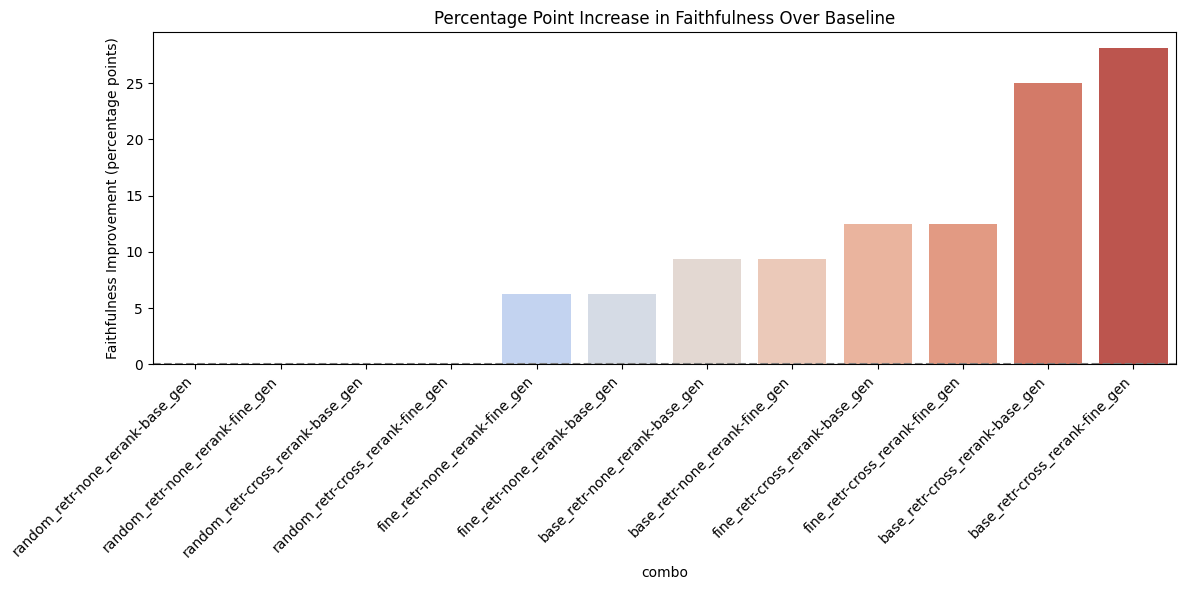

In [ ]:
df = pd.read_csv("llm_judge_ablation_test.csv")

# Baseline
baseline_score = df.loc[0, 'GPT_Prec@5']

# percentage point increase
df['GPT_Prec@5_increase'] = (df['GPT_Prec@5'] - baseline_score) * 100

# Sort by increase
df_sorted = df.sort_values('GPT_Prec@5_increase', ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='combo',
    y='GPT_Prec@5_increase',
    data=df_sorted,
    palette='coolwarm'
)
plt.axhline(0, color='gray', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Faithfulness Improvement (percentage points)")
plt.title("Percentage Point Increase in Faithfulness Over Baseline")
plt.tight_layout()
plt.show()


/tmp/ipython-input-1031812754.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


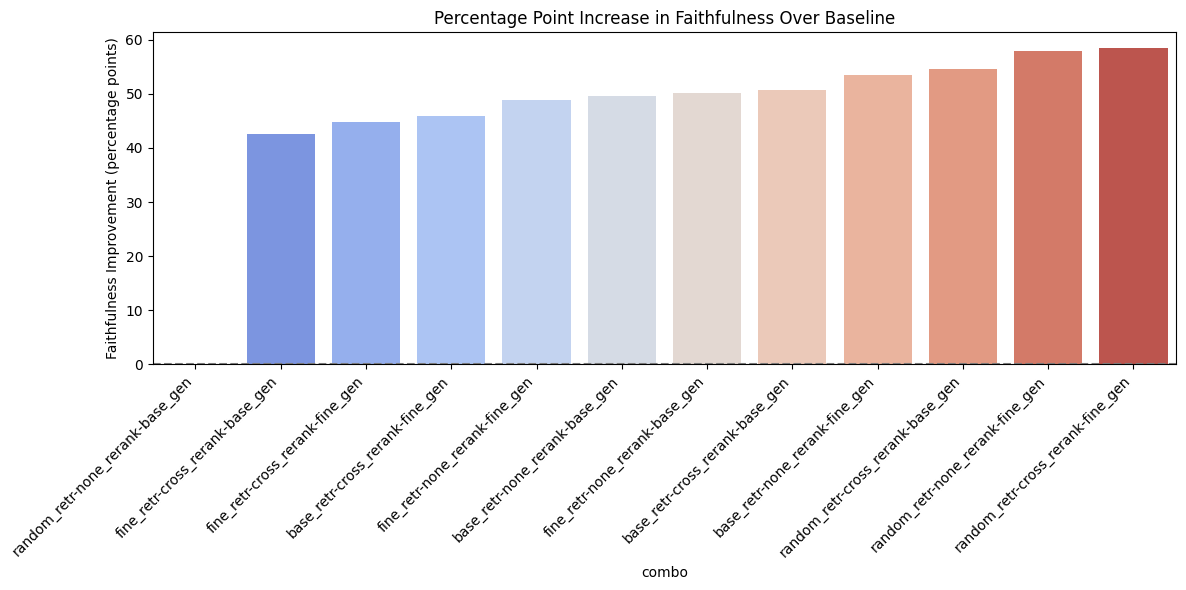

In [ ]:
baseline_score = df.loc[0, 'Entailment_avg']

# percentage point increase
df['Entailment_avg_increase'] = (df['Entailment_avg'] - baseline_score) * 100

# Sort by increase
df_sorted = df.sort_values('Entailment_avg_increase', ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='combo',
    y='Entailment_avg_increase',
    data=df_sorted,
    palette='coolwarm'
)
plt.axhline(0, color='gray', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Faithfulness Improvement (percentage points)")
plt.title("Percentage Point Increase in Faithfulness Over Baseline")
plt.tight_layout()
plt.show()

/tmp/ipython-input-504238939.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


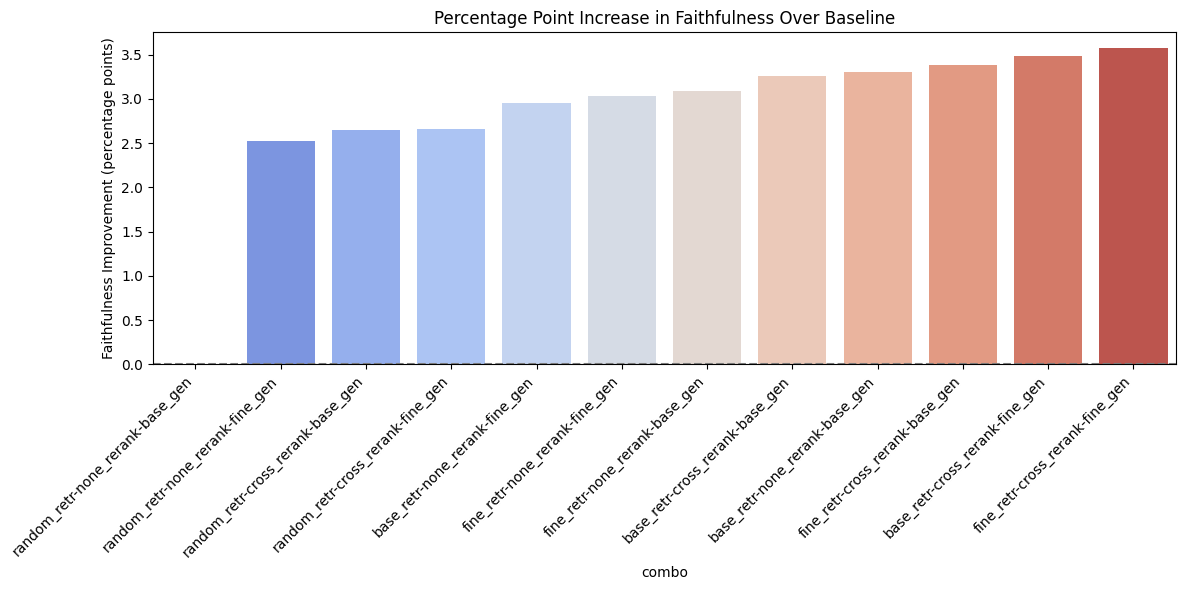

In [ ]:
baseline_score = df.loc[0, 'BERTScore_F1']

# percentage point increase
df['BERTScore_F1_increase'] = (df['BERTScore_F1'] - baseline_score) * 100

# Sort by increase
df_sorted = df.sort_values('BERTScore_F1_increase', ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='combo',
    y='BERTScore_F1_increase',
    data=df_sorted,
    palette='coolwarm'
)
plt.axhline(0, color='gray', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Faithfulness Improvement (percentage points)")
plt.title("Percentage Point Increase in Faithfulness Over Baseline")
plt.tight_layout()
plt.show()

/tmp/ipython-input-830438105.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


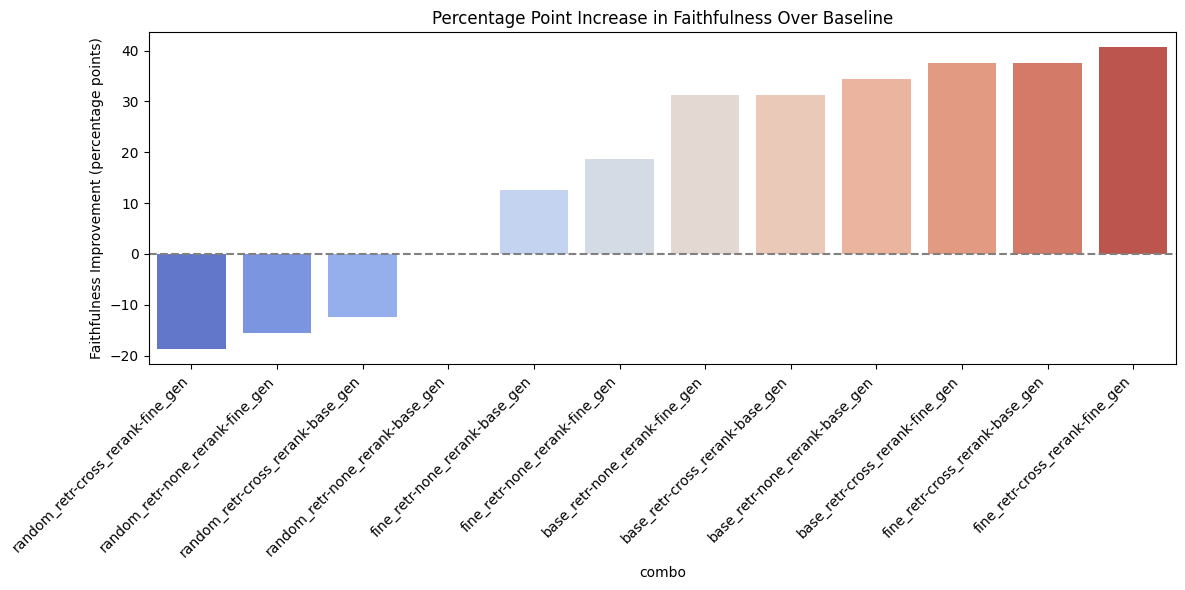

In [ ]:
df = pd.read_csv("llm_judge_ablation_test.csv")

# Baseline
baseline_score = df.loc[0, 'GPT_Faith']

# percentage point increase
df['GPT_Faith_increase'] = (df['GPT_Faith'] - baseline_score) * 100

# Sort by increase
df_sorted = df.sort_values('GPT_Faith_increase', ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='combo',
    y='GPT_Faith_increase',
    data=df_sorted,
    palette='coolwarm'
)
plt.axhline(0, color='gray', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Faithfulness Improvement (percentage points)")
plt.title("Percentage Point Increase in Faithfulness Over Baseline")
plt.tight_layout()
plt.show()
